In [110]:
import os
import re
import zipfile
import urllib.request
from collections import Counter
from spellchecker import SpellChecker
import re

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, GRU, Dropout, Bidirectional, SpatialDropout1D
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

from tokenizers import normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase

# Download NLTK resources
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [89]:
# Configure GPU - use only GPU 0
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Optionally limit GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f'Using GPU: {gpus[0].name}')
    except RuntimeError as e:
        print(e)
else:
    print('No GPU available, using CPU')


No GPU available, using CPU


In [ ]:
# checkimg data if exist
os.path.exists('../data/GrammarandProductReviews.csv') 

True

In [5]:
df = pd.read_csv('../data/GrammarandProductReviews.csv')
df.head()

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.02537E+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,NaN,0.0,5,https://redsky.target.com/groot-domain-api/v1/...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,Joshua,6.02537E+11
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor. This review was collected as part...,Good,NaN,NaN,Dorothy W,73416000391
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor.,Good,NaN,NaN,Dorothy W,73416000391
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,113026909.0,NaN,1,https://www.walmart.com/reviews/product/43383370,I read through the reviews on here before look...,Disappointed,NaN,NaN,Rebecca,67981934427
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,171267657.0,NaN,1,https://www.walmart.com/reviews/product/43383370,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,Walker557,67981934427


In [23]:
# Drop rows without ratings first, "subset = filter" 
df_clean = df.dropna(subset=['reviews.rating']).copy()
df_clean['rating'] = df_clean['reviews.rating'].astype(int)

# Shift scores
score_min = df_clean['rating'].min()
# print(df_clean['rating'])
# print(score_min)
df_clean['score_shifted'] = df_clean['rating'] - score_min
# print(df_clean['score_shifted'])
df_clean.head()

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc,last_char,ends_correctly,rating,score_shifted
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.02537E+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,Joshua,6.02537E+11,.,True,5,4
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,Good flavor. This review was collected as part...,Good,NaN,NaN,Dorothy W,73416000391,.,True,5,4
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,Good flavor.,Good,NaN,NaN,Dorothy W,73416000391,.,True,5,4
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,I read through the reviews on here before look...,Disappointed,NaN,NaN,Rebecca,67981934427,.,True,1,0
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,Walker557,67981934427,.,True,1,0


### 1.EDA

#### 1.1.Do reviewers use punctuation correctly?

In [ ]:
#  Clean trailing spaces and grab the last character
# We use .astype(str) to ensure no errors with empty reviews
# To use specialized string functions (like slicing or stripping),
#  you must "unlock" the string toolkit by adding .str.
# .astype(str): Makes the data a string.
# .str: Tells Pandas: "I’m about to do a string operation on every row in this column

# .str.strip()
# This does not get rid of the last letter; it removes "whitespace" (invisible spaces, tabs, or newlines)
# from the very beginning and very end of the text.
df_clean['last_char'] = df_clean['reviews.text'].astype(str).str.strip().str[-1]
# print(df['last_char'])

# Code Piece                 Action,                   "Result on ""Great!  """
# .astype(str),        Changes type to string,          """Great!  """
# .str.strip(),        Removes end spaces,               """Great!"""
# .str[-1],            Grabs the last character,          """!"""

# Define valid punctuation
valid_punc = ['.', '!', '?']

# Check if the last character is valid
df_clean['ends_correctly'] = df['last_char'].isin(valid_punc)
# print(df['ends_correctly'])
# Get the count of those who DON'T use it correctly
incorrect_count = len(df) - df['ends_correctly'].sum()
proportion = (incorrect_count / len(df)) * 100

print(f"Number of reviews missing end punctuation: {incorrect_count}")
print(f"Percentage of incorrect punctuation: {proportion:.2f}%")

0         True
1         True
2         True
3         True
4         True
         ...  
71039     True
71040     True
71041    False
71042     True
71043     True
Name: ends_correctly, Length: 71044, dtype: bool
Number of reviews missing end punctuation: 12692
Percentage of incorrect punctuation: 17.86%


#### 1.2.Does the number of spelling errors differ by rating?

In [22]:
spell = SpellChecker()
#re.findall(r'\b\w+\b', ...) ==> Think of this as a magnet that only picks up letters and numbers, leaving everything else (punctuation) behind.
# Input: "The food was grate!!"   ==> Output: ['the', 'food', 'was', 'grate']

def count_spelling_errors(text):
    # Removing punctuation and numbers, keeping only words so , i can check only words
    words = re.findall(r'\b\w+\b', str(text).lower())
    
    # finding which words are not in spell list which mean all the dataset
    misspelled = spell.unknown(words)
    
    return len(misspelled)



df_sample = df_clean.head(500).copy()
df_sample['spelling_errors'] = df_sample['reviews.text'].apply(count_spelling_errors)

# Group by rating and find the average
spelling_trend = df_sample.groupby('rating')['spelling_errors'].mean()

print("Average Spelling Errors by Rating:")
print(spelling_trend)

Average Spelling Errors by Rating:
rating
1    0.714286
2    0.750000
3    0.666667
4    0.517857
5    0.653495
Name: spelling_errors, dtype: float64


#### 1.3.What is the distribution of star ratings across products?

In [76]:
# getting brands(products)
top_10_products = df_clean['brand'].value_counts().nlargest(10).index


# Calculate the AVERAGE rating for those specific brands
# We group by brand and then take the mean of the rating
top_10_averages = df_clean.groupby('brand')['rating'].mean().loc[top_10_products]
# top_10_products
top_10_averages  



brand
Clorox                  4.825421
Universal Home Video    4.663807
Tide                    4.168091
FOX                     4.107603
Disney                  4.722914
Olay                    4.193567
Warner Home Video       4.349550
L'Oreal Paris           4.352218
L'oreal Paris           4.495629
Sony Pictures           4.357242
Name: rating, dtype: float64

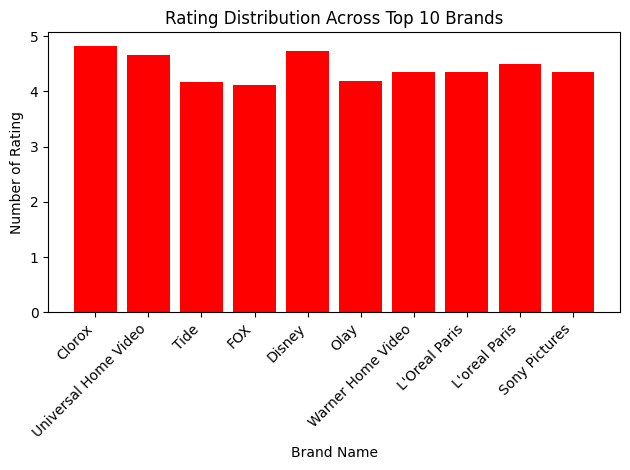

In [ ]:
# 4. Plot it
plt.bar(top_10_products, top_10_averages , color='red')
plt.title('Rating Distribution Across Top 10 Brands')
plt.xlabel('Brand Name')
plt.ylabel('Average of Rating')
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()

### 2.Preprocess the dataset by :

#### 2.1.Generating a binary target variable from ratings (positive / negative sentiment)

In [79]:
# creating binary target
# If rating is greater than 3, it becomes 1 (Positive). Otherwise, it becomes 0 (Negative)
# astye(int) --> this return true false to 1,0 
df_clean['target'] = (df_clean['rating'] > 3).astype(int)


# See how many of each we have
print("\nTarget Distribution:")
print(df_clean['target'].value_counts())


Target Distribution:
target
1    61141
0     9903
Name: count, dtype: int64


#### 2.2.Clean the Data - Common NLP Data Cleaning Techniques -

##### 2.2.1.Normalizing the Texts ("Héllò hôw are ü?" --> "Hello how are u?")

In [86]:
# This should work now!
normalizer = normalizers.Sequence([NFD(), Lowercase(), StripAccents()])

df_clean['clean_text'] = df_clean['reviews.text'].astype(str).apply(lambda x:normalizer.normalize_str(x))

print(df_clean['clean_text'].head())

0    i love this album. it's very good. more to the...
1    good flavor. this review was collected as part...
2                                         good flavor.
3    i read through the reviews on here before look...
4    my husband bought this gel for us. the gel cau...
Name: clean_text, dtype: object


#### 2.2.2.Removing stop-words ("The black cat is a menace." ---> "black cat is menace.")

In [ ]:

# DOWNLOADS - Run these once
# 1. Download EVERY piece of data NLTK might ask for
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Set up stop words and tokenizer
stop_words = set(stopwords.words('english'))

def clean_with_tokenizer(text):

        # doing same thins as "split()" method
        words = word_tokenize(str(text))

        # filtering stop-words
        filtered = [w for w in words if w.lower() not in stop_words and w.isalpha()]

        # Why do we need " ".join(filtered)?
        # When you use a tokenizer, it turns your sentence into a List of strings.
        # Input: "The cat sat."
        # After Tokenizer & Filtering: ['cat', 'sat'] (A Python List)
        return " ".join(filtered)


[nltk_data] Downloading package punkt to /home/vscode/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/vscode/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [112]:
df_clean['clean_text'] = df_clean['clean_text'].apply(clean_with_tokenizer)

In [113]:
print(df_clean['clean_text'].head())

0    love album good hip hop side current pop sound...
1          good flavor review collected part promotion
2                                          good flavor
3    read reviews looking buying one couples lubric...
4    husband bought gel us gel caused irritation fe...
Name: clean_text, dtype: object
